# Explore Workouts 🏋️

**Goal of this notebook:** take a look at what's actually landed in `workouts.db`
so far, before building anything more on top of it. This is exploratory only —
just pandas + a bit of matplotlib, and it never writes to the database.

1. Load the whole `sets` table into a DataFrame.
2. Get a basic summary: activity/set counts, how many rows Garmin failed to
   auto-detect, and the date range covered.
3. Break sets down per exercise (ignoring the undetected `UNKNOWN` rows).
4. List the `UNKNOWN` rows on their own — these are what `review_workouts.py`
   needs to fix.
5. Plot weight vs. set number for one exercise, to eyeball whether there's a
   natural progression (e.g. going heavier each set) within a workout.

## 1. Load the `sets` table

We open the database with SQLite's `mode=ro` (read-only) URI flag, so it's
physically impossible for this notebook to write to `workouts.db` — only
`fetch_latest_workout.py` and `review_workouts.py` do that.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd

# Resolve the repo root the same way the other notebooks do, so this works
# whether Jupyter's working directory is the repo root or notebooks/.
REPO_ROOT = Path.cwd() if (Path.cwd() / "garminconnect").exists() else Path.cwd().parent
DB_PATH = REPO_ROOT / "workouts.db"

conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
sets_df = pd.read_sql("SELECT * FROM sets", conn)
conn.close()

sets_df

,activity_id,exercise_name,set_number,reps,weight_kg,source,date_recorded,manually_corrected
0,23461943618,SHRUG,1,13,NaN,garmin_auto,2026-07-03,0
1,23461943618,ROW,1,14,NaN,garmin_auto,2026-07-03,0
2,23461943618,PULL_UP,1,12,NaN,garmin_auto,2026-07-03,0
3,23461943618,LUNGE,1,16,NaN,garmin_auto,2026-07-03,0
4,23461943618,DUMBBELL_FLYE,1,7,NaN,garmin_auto,2026-07-03,0
5,23461943618,SEATED_CABLE_ROW,1,7,NaN,garmin_auto,2026-07-03,0
6,23461943618,SEATED_CABLE_ROW,2,7,NaN,garmin_auto,2026-07-03,0
7,23461943618,UNKNOWN,1,6,NaN,garmin_auto,2026-07-03,0
8,23461943618,UNKNOWN,2,0,NaN,garmin_auto,2026-07-03,0
9,23461943618,UNKNOWN,3,0,NaN,garmin_auto,2026-07-03,0


## 2. Basic summary

How much data do we have, and how much of it did Garmin actually manage to
identify? A row counts as a "detection gap" when `exercise_name` is
`"UNKNOWN"` — that's Garmin's own "couldn't classify this" placeholder. We
don't use `weight_kg == 0` as a gap signal on its own, because bodyweight
exercises (push-ups, pull-ups, etc.) legitimately have 0 kg.

In [2]:
is_unknown = sets_df["exercise_name"] == "UNKNOWN"

print(f"Activities in the database : {sets_df['activity_id'].nunique()}")
print(f"Total sets recorded        : {len(sets_df)}")
print(f"UNKNOWN / undetected sets  : {is_unknown.sum()}")
print(f"Properly detected sets     : {(~is_unknown).sum()}")
print(
    f"Date range covered         : "
    f"{sets_df['date_recorded'].min()} to {sets_df['date_recorded'].max()}"
)

Activities in the database : 1
Total sets recorded        : 22
UNKNOWN / undetected sets  : 12
Properly detected sets     : 10
Date range covered         : 2026-07-03 to 2026-07-03


## 3. Per-exercise breakdown

Grouping by `exercise_name` (excluding `UNKNOWN`, since it isn't a real
exercise) to see how many sets, the heaviest weight, and total reps logged
per exercise so far.

In [3]:
detected = sets_df[sets_df["exercise_name"] != "UNKNOWN"]

exercise_summary = (
    detected.groupby("exercise_name")
    .agg(
        num_sets=("set_number", "count"),
        max_weight_kg=("weight_kg", "max"),
        total_reps=("reps", "sum"),
    )
    .sort_values("num_sets", ascending=False)
)

exercise_summary

,num_sets,max_weight_kg,total_reps
exercise_name,,,
PUSH_UP,2,0.0,15
SEATED_CABLE_ROW,2,NaN,14
BARBELL_DEADLIFT,1,0.0,6
DUMBBELL_FLYE,1,NaN,7
LUNGE,1,NaN,16
PULL_UP,1,NaN,12
ROW,1,NaN,14
SHRUG,1,NaN,13


## 4. Rows that still need manual correction

Just the `UNKNOWN` rows, identified by `activity_id` + `set_number` so they're
easy to find and fix in `review_workouts.py`.

In [4]:
unknown_rows = sets_df.loc[
    sets_df["exercise_name"] == "UNKNOWN",
    ["activity_id", "set_number", "date_recorded"],
]

unknown_rows

,activity_id,set_number,date_recorded
7,23461943618,1,2026-07-03
8,23461943618,2,2026-07-03
9,23461943618,3,2026-07-03
10,23461943618,4,2026-07-03
11,23461943618,5,2026-07-03
12,23461943618,6,2026-07-03
13,23461943618,7,2026-07-03
15,23461943618,8,2026-07-03
18,23461943618,9,2026-07-03
19,23461943618,10,2026-07-03


## 5. Weight progression within one exercise

Picking whichever detected exercise has the most sets logged, and plotting
`weight_kg` against `set_number` to see if weight tends to climb (or drop)
as the sets go on.

Matplotlib is building the font cache; this may take a moment.


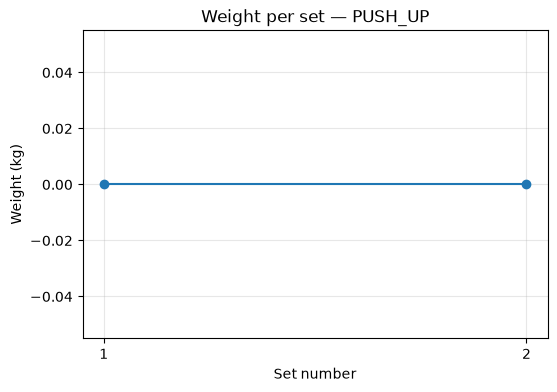

In [5]:
import matplotlib.pyplot as plt

top_exercise = exercise_summary["num_sets"].idxmax()
exercise_sets = detected[detected["exercise_name"] == top_exercise].sort_values("set_number")

plt.figure(figsize=(6, 4))
plt.plot(exercise_sets["set_number"], exercise_sets["weight_kg"], marker="o")
plt.title(f"Weight per set — {top_exercise}")
plt.xlabel("Set number")
plt.ylabel("Weight (kg)")
plt.xticks(exercise_sets["set_number"])
plt.grid(True, alpha=0.3)
plt.show()